# Project 3: Trapped in a Low Dimension
## Exploring Neural Population Dynamics through Dimensionality Reduction
### MICrONS Dataset — Mouse Visual Cortex (V1)

**Course:** Neuroscience Computation  
**Dataset:** MICrONS Functional + Structural Connectomics (version 1718)  
**Session analysed:** `9_4`

---

## 1. Introduction

The visual cortex encodes sensory information through the coordinated activity
of thousands of neurons.  Each neuron contributes one dimension to the population
state, so the space of possible activity patterns is extremely high-dimensional.
A central hypothesis in systems neuroscience — the **neural manifold hypothesis**
— posits that, despite this high dimensionality, the brain actually operates on
a much lower-dimensional surface, because neural activity is strongly structured
by the statistics of natural inputs and by the architecture of the circuit.

This project exploits the **MICrONS** dataset, which pairs two-photon calcium
imaging of tens of thousands of V1 neurons in a live mouse with a millimetre-scale
electron-microscopy reconstruction of the same tissue.  The functional recording
covers several types of visual stimuli (parametric patterns, natural movie clips),
giving us rich coverage of the neural response space.

We apply **PCA**, **t-SNE**, **UMAP**, and (optionally) **CEBRA** to the
population response matrix and ask:

* Does the neural population trace out a low-dimensional manifold?
* Can different stimulus types be distinguished from the geometry of that manifold?
* Do different algorithms agree on the structure they reveal?
* Do temporally adjacent movie frames sit nearby in the embedding?

These questions connect directly to course material on population codes,
representational geometry, and the structure of sensory cortex.

## 2. Research Questions

1. **Stimulus discriminability** — Can the type of visual stimulus being shown
   be decoded from the low-dimensional representation of population activity?
   If so, stimulus identity is encoded in the *geometry* of the neural manifold.

2. **Algorithm agreement** — Do PCA, t-SNE, and UMAP converge on the same
   structure?  PCA captures linear variance; the nonlinear methods may reveal
   additional structure.  Agreement across methods argues for robustness.

3. **Intrinsic dimensionality** — How many principal components are needed to
   explain most of the population variance?  This constrains theories of neural
   coding and the complexity of the underlying computation.

4. **Temporal continuity** — For naturalistic movie clips, do temporally
   adjacent frames cluster nearby in the embedding?  This would suggest the
   manifold tracks visual dynamics smoothly.

## 3. Setup & Imports

In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# ── Dimensionality-reduction ─────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import ttest_ind, ttest_1samp, wilcoxon

# ── UMAP (umap-learn) ─────────────────────────────────────────────────────────
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP        ✓  (umap-learn)")
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP        ✗  — install: pip install umap-learn")

# ── CEBRA (optional) ──────────────────────────────────────────────────────────
try:
    import cebra
    CEBRA_AVAILABLE = True
    print("CEBRA       ✓")
except ImportError:
    CEBRA_AVAILABLE = False
    print("CEBRA       ✗  — install: pip install cebra  (optional)")

# ── MICrONS tools ─────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

print("\nAll core imports successful ✓")

UMAP        ✓  (umap-learn)
CEBRA       ✓

All core imports successful ✓


In [2]:
# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'legend.frameon'  : False,
    'savefig.bbox'    : 'tight',
})
SEED = 42

## 4. Data Loading

We follow the same pattern as the tutorial: use `MicronsDataCleaner` to
download the nucleus/segment metadata, then `MicronsFunctionalReader` for the
calcium-imaging traces.  We restrict to V1 neurons with clean axonal
proofreading and matched tuning data.

In [3]:
# ── Anatomical + functional metadata ────────────────────────────────────────
cleaner = mic.MicronsDataCleaner(datadir="data/", version=1718)
cleaner.download_nucleus_data()   # run once — writes CSVs to data/1718/raw/

units, segments = cleaner.process_nucleus_data(functional_data='best_only')
print(f"Total units loaded : {len(units)}")
print(f"Columns            : {list(units.columns)}")
units.head()

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 113139.02it/s]


Total units loaded : 90434
Columns            : ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'tuning_type', 'layer']


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6


In [4]:
# ── Filter to V1, proofread, matched tuning ─────────────────────────────────
v1_neurons = fl.filter_neurons(units, brain_area='V1',
                               proofread='ax_clean', tuning='matched')

v1_exc = v1_neurons[v1_neurons['classification_system'] == 'excitatory_neuron']
v1_inh = v1_neurons[v1_neurons['classification_system'] == 'inhibitory_neuron']

print(f"V1 neurons (proofread, matched): {len(v1_neurons)}")
print(f"  Excitatory : {len(v1_exc)}")
print(f"  Inhibitory : {len(v1_inh)}")
print()
print(v1_neurons['classification_system'].value_counts())

V1 neurons (proofread, matched): 728
  Excitatory : 728
  Inhibitory : 0

classification_system
excitatory_neuron    728
Name: count, dtype: int64


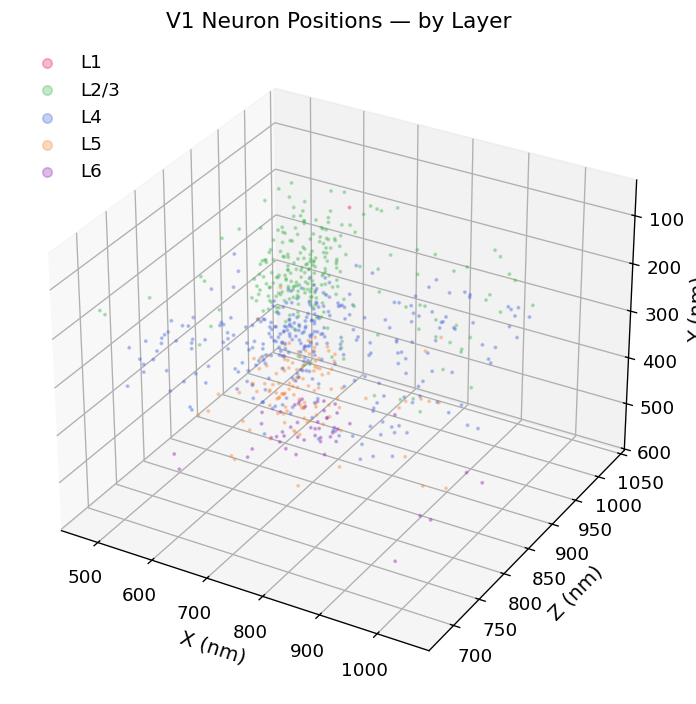

In [5]:
# ── 3-D spatial map of neurons by layer ─────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')
ax.zaxis.set_inverted(True)

LAYER_COLORS = {
    'L1'  : '#e6194b', 'L2/3': '#3cb44b',
    'L4'  : '#4363d8', 'L5'  : '#f58231', 'L6': '#911eb4'
}

for layer, color in LAYER_COLORS.items():
    ul = fl.filter_neurons(v1_neurons, layer=layer)
    if len(ul):
        ax.scatter(ul['pt_position_x'], ul['pt_position_z'], ul['pt_position_y'],
                   alpha=0.3, s=2, color=color, label=layer)

ax.set_xlabel('X (nm)'); ax.set_ylabel('Z (nm)'); ax.set_zlabel('Y (nm)')
ax.set_title('V1 Neuron Positions — by Layer')
ax.legend(markerscale=4, loc='upper left')
plt.tight_layout(); plt.show()

## 5. Building the Population Response Matrix

### Methodology

For each trial in session **9_4** we retrieve the response array
`r['responses']` of shape `(n_neurons, n_frames)`.  We average across frames
to obtain a single population response vector per trial, then group trials by
their stimulus hash (= unique visual stimulus) and average across repeated
presentations.

The result is a matrix **R** of shape `(n_unique_stimuli, n_neurons)`.  Each
row is a point in neuron-space; each column is one neuron's average response to
that stimulus.  This is the input to all dimensionality-reduction steps.

In [6]:
# ── Functional reader & trial inventory ─────────────────────────────────────
SESSION = "9_4"
funcreader = mic.MicronsFunctionalReader(path="microns.h5")
hashes = funcreader.get_hashes_by_session(SESSION)

stim_types = [funcreader.get_video_type(h) for h in hashes]
type_counts = Counter(stim_types)

print(f"Total trials in session {SESSION}: {len(hashes)}")
print("\nStimulus types:")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:22s}: {v:4d} trials")

Total trials in session 9_4: 464

Stimulus types:
  Clip                  :  384 trials
  Monet2                :   40 trials
  Trippy                :   40 trials


In [7]:
# ── Collect per-trial mean responses ─────────────────────────────────────────
# hash_to_responses[h] = list of (n_neurons,) vectors, one per presentation
hash_to_responses = defaultdict(list)
hash_to_type      = {}

print("Loading trial responses ... (may take a few minutes)")
n_failed = 0

for trial_idx, h in enumerate(hashes):
    hash_to_type[h] = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        # r['responses']: (n_neurons, n_frames)
        mean_resp = r['responses'].mean(axis=1)   # → (n_neurons,)
        hash_to_responses[h].append(mean_resp)
    except Exception:
        n_failed += 1

print(f"  Done.  {len(hash_to_responses)} unique stimuli loaded  |  {n_failed} trials skipped")

Loading trial responses ... (may take a few minutes)
  Done.  280 unique stimuli loaded  |  0 trials skipped


In [8]:
# ── Average across repeated presentations → final R matrix ──────────────────
unique_hashes = sorted(hash_to_responses.keys())
R_matrix  = np.array([np.mean(hash_to_responses[h], axis=0) for h in unique_hashes])
labels_raw = np.array([hash_to_type[h] for h in unique_hashes])

print(f"Response matrix shape : {R_matrix.shape}")
print(f"  rows = unique stimuli,  cols = neurons")
print()
print("Stimulus distribution in R:")
for lbl, cnt in Counter(labels_raw).items():
    print(f"  {lbl:22s}: {cnt}")

Response matrix shape : (280, 7855)
  rows = unique stimuli,  cols = neurons

Stimulus distribution in R:
  Trippy                : 20
  Clip                  : 240
  Monet2                : 20


## 6. Preprocessing

Before running dimensionality reduction we:

1. **Remove noisy neurons** — drop columns with >10 % NaN across stimuli.
2. **Impute remaining NaNs** — replace with the per-neuron mean.
3. **Remove silent stimuli** — drop rows with no variation (all-zero or constant).
4. **Z-score across stimuli** — subtract the mean and divide by the standard
   deviation of each neuron across stimuli.  This ensures that neurons with
   different baseline firing rates contribute equally.

In [9]:
# ── 1. Drop high-NaN neurons ─────────────────────────────────────────────────
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
print(f"Neurons after NaN filter : {keep_neurons.sum()} / {R_matrix.shape[1]}")

# ── 2. Impute remaining NaNs ─────────────────────────────────────────────────
col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

# ── 3. Drop near-silent stimuli ──────────────────────────────────────────────
active      = R_clean.std(axis=1) > 1e-6
R_clean     = R_clean[active]
labels      = labels_raw[active]
print(f"Stimuli after activity filter : {active.sum()} / {R_matrix.shape[0]}")

# ── 4. Z-score ───────────────────────────────────────────────────────────────
scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)

print(f"\nFinal response matrix : {R_scaled.shape}")
print(f"  Mean : {R_scaled.mean():+.4f}  (should ≈ 0)")
print(f"  Std  : {R_scaled.std():+.4f}  (should ≈ 1)")

Neurons after NaN filter : 7855 / 7855
Stimuli after activity filter : 280 / 280

Final response matrix : (280, 7855)
  Mean : -0.0000  (should ≈ 0)
  Std  : +1.0000  (should ≈ 1)


Stimulus distribution:
  Clip                    n= 240  (85.7 %)
  Monet2                  n=  20  (7.1 %)
  Trippy                  n=  20  (7.1 %)

Majority-class standard-accuracy baseline : 0.857
Uniform chance / balanced-accuracy baseline : 0.333
=> Standard accuracy is misleading. Primary metrics: balanced accuracy + macro F1.


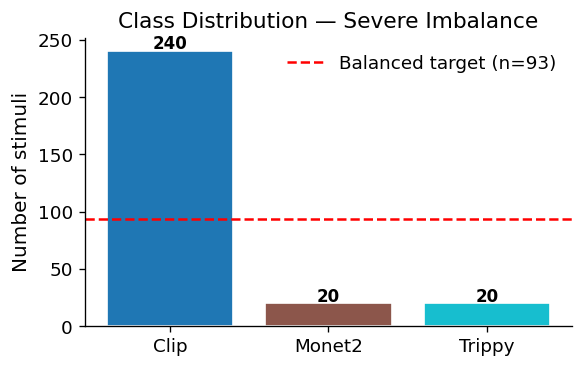


Balanced subsample: 20 per class x 3 = 60 total
  Clip: 20
  Monet2: 20
  Trippy: 20

Balanced LogisticRegression + StratifiedKFold-5 initialised.


In [10]:
# ── Colour coding for stimulus types ─────────────────────────────────────────
unique_labels  = sorted(set(labels))
n_types        = len(unique_labels)
palette        = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
label_to_idx   = {lbl: i          for i, lbl in enumerate(unique_labels)}

le             = LabelEncoder()
y              = le.fit_transform(labels)
chance_level   = 1.0 / n_types
counts         = {lbl: int(np.sum(labels == lbl)) for lbl in unique_labels}
majority_frac  = max(counts.values()) / len(labels)
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

# ── Class balance summary & warning ──────────────────────────────────────────
print("Stimulus distribution:")
for lbl, n in counts.items():
    print(f"  {lbl:22s}  n={n:4d}  ({100*n/len(labels):.1f} %)")

print(f"\nMajority-class standard-accuracy baseline : {majority_frac:.3f}")
print(f"Uniform chance / balanced-accuracy baseline : {chance_level:.3f}")
print("=> Standard accuracy is misleading. Primary metrics: balanced accuracy + macro F1.")

# ── Class balance bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(list(counts.keys()), list(counts.values()),
              color=[label_to_color[l] for l in counts], edgecolor='white')
ax.axhline(len(labels) / n_types, color='red', ls='--',
           label=f'Balanced target (n={len(labels)//n_types})')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of stimuli')
ax.set_title('Class Distribution — Severe Imbalance')
ax.legend(); plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=150); plt.show()

# ── Balanced subsample (equal n per class) ────────────────────────────────────
rng_bal   = np.random.default_rng(seed=SEED)
N_BAL     = int(min(counts.values()))
bal_idx   = np.concatenate([
    rng_bal.choice(np.where(labels == lbl)[0], size=N_BAL, replace=False)
    for lbl in unique_labels
])
bal_idx    = np.sort(bal_idx)
y_bal      = y[bal_idx]
labels_bal = labels[bal_idx]
R_bal      = R_scaled[bal_idx]

print(f"\nBalanced subsample: {N_BAL} per class x {n_types} = {len(bal_idx)} total")
for lbl in unique_labels:
    print(f"  {lbl}: {int(np.sum(labels_bal == lbl))}")

# ── Shared classifier / CV objects (balanced throughout) ─────────────────────
cv_bal  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED,
                              class_weight='balanced')
print("\nBalanced LogisticRegression + StratifiedKFold-5 initialised.")


## 7. Dimensionality Reduction

### 7a. Principal Component Analysis (PCA)

PCA finds the linear subspace that captures the most variance.  The *scree
plot* and *cumulative variance curve* reveal the intrinsic dimensionality of
the population code.  We fit up to **150 PCs** — enough to actually cross the
80 % and 90 % variance thresholds.  Two additional diagnostics are reported:

* **Participation ratio** — model-free effective dimensionality,
  PR = (Σλᵢ)² / Σλᵢ² ; equals 1 when one PC dominates, equals N when variance
  is spread uniformly.
* **Cumulative variance at key depths** — PC1+2, PC1–10, and the thresholds for
  80 % and 90 % explained variance.

A high PR and many PCs needed to reach 80 % argue for a *high-dimensional*
population code rather than a low-dimensional manifold.


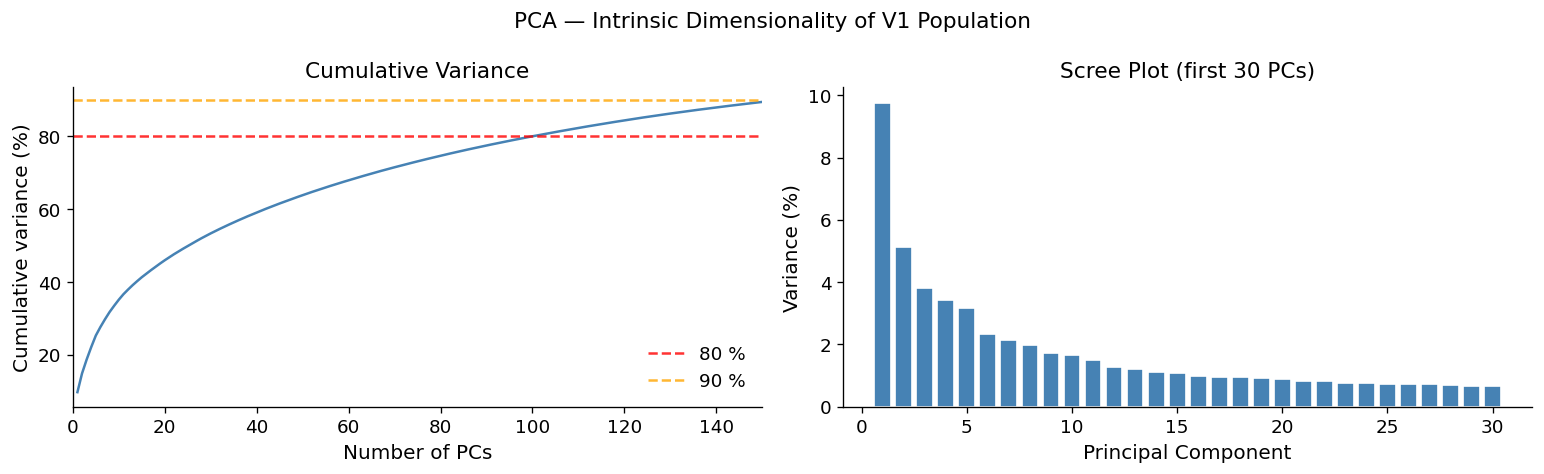

PCs for 80 % variance        : 100  
PCs for 90 % variance        : 150  (cap reached — need more PCs)
Variance in PC1              : 9.76 %
Variance in PC1+PC2          : 14.89 %
Variance in PC1-PC10         : 35.14 %
Total variance in 150 PCs    : 89.44 %
Participation ratio (eff dim): 48.1

Interpretation: participation ratio << n_neurons indicates a lower-dimensional
subspace, but PR >> 2-3 still means the manifold is not trivially 2D.


In [11]:
# ── Fit PCA (up to 150 components to reach variance thresholds) ───────────────
n_pcs = min(150, R_scaled.shape[0] - 1, R_scaled.shape[1] - 1)
pca   = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
ev     = pca.explained_variance_ratio_

# ── Participation ratio (effective dimensionality) ────────────────────────────
participation_ratio = 1.0 / np.sum(ev ** 2)

# ── Scree + cumulative variance ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, '-', lw=1.5, color='steelblue')
axes[0].axhline(80, color='red',    ls='--', alpha=0.8, label='80 %')
axes[0].axhline(90, color='orange', ls='--', alpha=0.8, label='90 %')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance'); axes[0].legend(); axes[0].set_xlim(0, n_pcs)

axes[1].bar(np.arange(1, 31), ev[:30] * 100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Variance (%)')
axes[1].set_title('Scree Plot (first 30 PCs)')

plt.suptitle('PCA — Intrinsic Dimensionality of V1 Population', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150); plt.show()

n80 = int(np.searchsorted(cumvar, 0.80)) + 1
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n80 = min(n80, n_pcs)   # cap at what was computed
n90 = min(n90, n_pcs)

print(f"PCs for 80 % variance        : {n80}  {'(cap reached — need more PCs)' if n80==n_pcs and cumvar[-1]<0.80 else ''}")
print(f"PCs for 90 % variance        : {n90}  {'(cap reached — need more PCs)' if n90==n_pcs and cumvar[-1]<0.90 else ''}")
print(f"Variance in PC1              : {ev[0]*100:.2f} %")
print(f"Variance in PC1+PC2          : {cumvar[1]*100:.2f} %")
print(f"Variance in PC1-PC10         : {cumvar[9]*100:.2f} %")
print(f"Total variance in {n_pcs} PCs    : {cumvar[-1]*100:.2f} %")
print(f"Participation ratio (eff dim): {participation_ratio:.1f}")
print()
print("Interpretation: participation ratio << n_neurons indicates a lower-dimensional")
print("subspace, but PR >> 2-3 still means the manifold is not trivially 2D.")


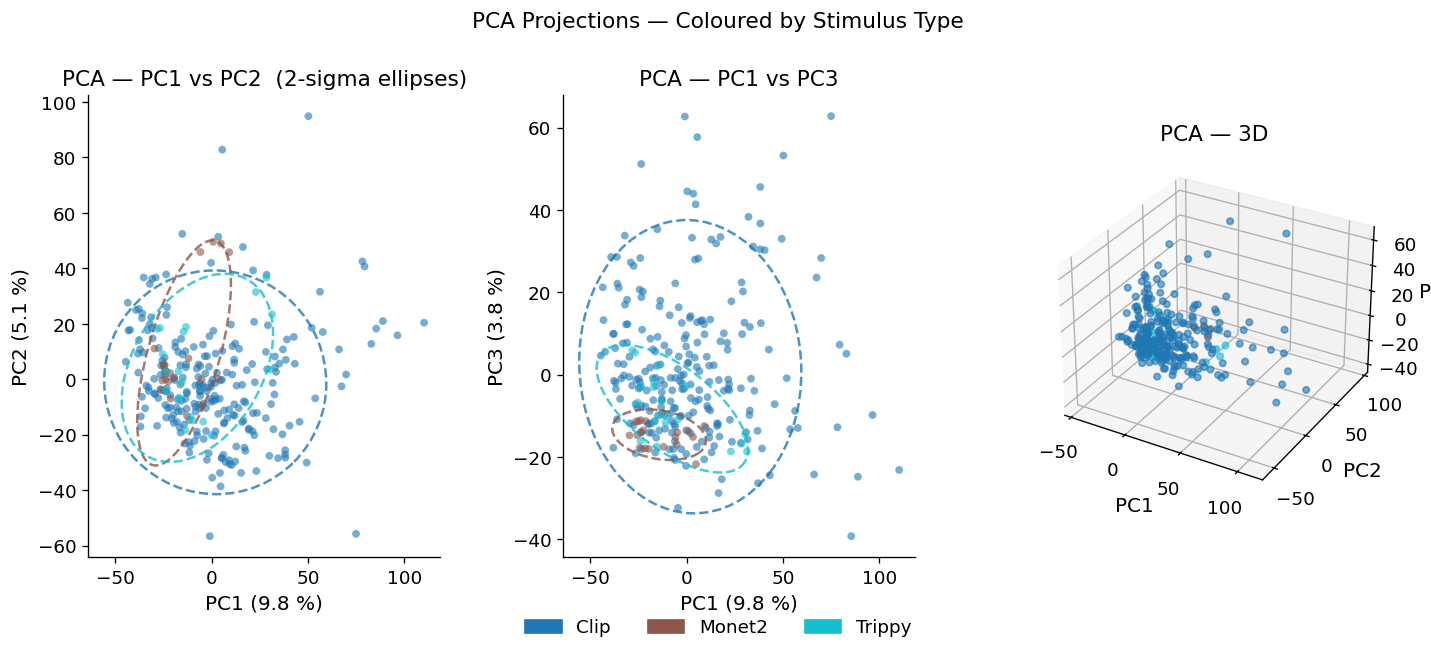

In [12]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    t = (transforms.Affine2D()
         .rotate_deg(45)
         .scale(scale_x, scale_y)
         .translate(x.mean(), y.mean()))
    ellipse.set_transform(t + ax.transData)
    return ax.add_patch(ellipse)

# ── PCA 2-D and 3-D scatter ───────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
for lbl in unique_labels:
    m = labels == lbl
    ax1.scatter(R_pca[m,0], R_pca[m,1], color=label_to_color[lbl],
                alpha=0.6, s=22, edgecolors='none', label=lbl)
    confidence_ellipse(R_pca[m,0], R_pca[m,1], ax1,
                       n_std=2, edgecolor=label_to_color[lbl],
                       facecolor='none', lw=1.5, ls='--', alpha=0.8)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)')
ax1.set_title('PCA — PC1 vs PC2  (2-sigma ellipses)')

ax2 = fig.add_subplot(gs[1])
for lbl in unique_labels:
    m = labels == lbl
    ax2.scatter(R_pca[m,0], R_pca[m,2], color=label_to_color[lbl],
                alpha=0.6, s=22, edgecolors='none')
    confidence_ellipse(R_pca[m,0], R_pca[m,2], ax2,
                       n_std=2, edgecolor=label_to_color[lbl],
                       facecolor='none', lw=1.5, ls='--', alpha=0.8)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax2.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f} %)')
ax2.set_title('PCA — PC1 vs PC3')

ax3 = fig.add_subplot(gs[2], projection='3d')
for lbl in unique_labels:
    m = labels == lbl
    ax3.scatter(R_pca[m,0], R_pca[m,1], R_pca[m,2],
                color=label_to_color[lbl], alpha=0.6, s=15)
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2'); ax3.set_zlabel('PC3')
ax3.set_title('PCA — 3D')

fig.legend(handles=legend_patches, loc='lower center',
           ncol=n_types, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('PCA Projections — Coloured by Stimulus Type', fontsize=13, y=1.02)
plt.savefig('fig_pca_scatter.png', dpi=150); plt.show()


### 7b. t-SNE

t-SNE is a nonlinear method that preserves local neighbourhood structure.
It is sensitive to the **perplexity** hyperparameter (≈ effective neighbourhood
size).  We run three values to check robustness.  t-SNE is applied to the first
50 PCA components — this is standard practice and both speeds up computation
and denoises the input.

In [13]:
# ── t-SNE ─────────────────────────────────────────────────────────────────────
n_pca_for_tsne = min(50, n_pcs)
tsne_results   = {}
PERPLEXITIES   = [15, 30, 50]

print("Running t-SNE for three perplexity values...")
for perp in PERPLEXITIES:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(R_pca[:, :n_pca_for_tsne])
    print(f"  perplexity={perp:3d}  ✓")

R_tsne = tsne_results[30]   # default for downstream analysis

Running t-SNE for three perplexity values...
  perplexity= 15  ✓
  perplexity= 30  ✓
  perplexity= 50  ✓


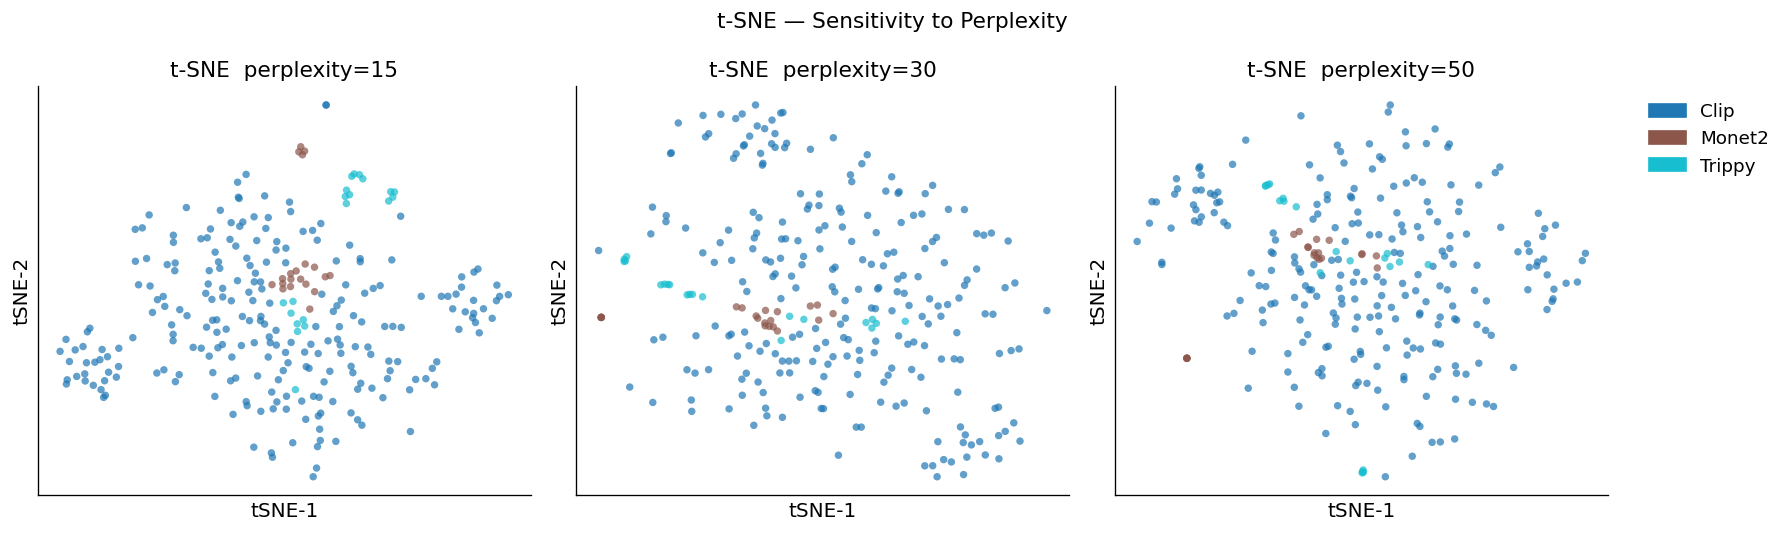

In [14]:
# ── t-SNE: perplexity comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, perp in zip(axes, PERPLEXITIES):
    R_t = tsne_results[perp]
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_t[m,0], R_t[m,1], color=label_to_color[lbl],
                   alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp}')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('tSNE-1'); ax.set_ylabel('tSNE-2')

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE — Sensitivity to Perplexity', fontsize=13)
plt.tight_layout()
plt.savefig('fig_tsne_perplexity.png', dpi=150); plt.show()

### 7c. UMAP

UMAP (Uniform Manifold Approximation and Projection) is faster than t-SNE and
better preserves global structure alongside local neighbourhoods.  The key
hyperparameter is **n_neighbors** (local neighbourhood size) and **min_dist**
(minimum distance in the embedding).

Running UMAP for three n_neighbors values...
  n_neighbors=  5  ✓
  n_neighbors= 15  ✓
  n_neighbors= 50  ✓


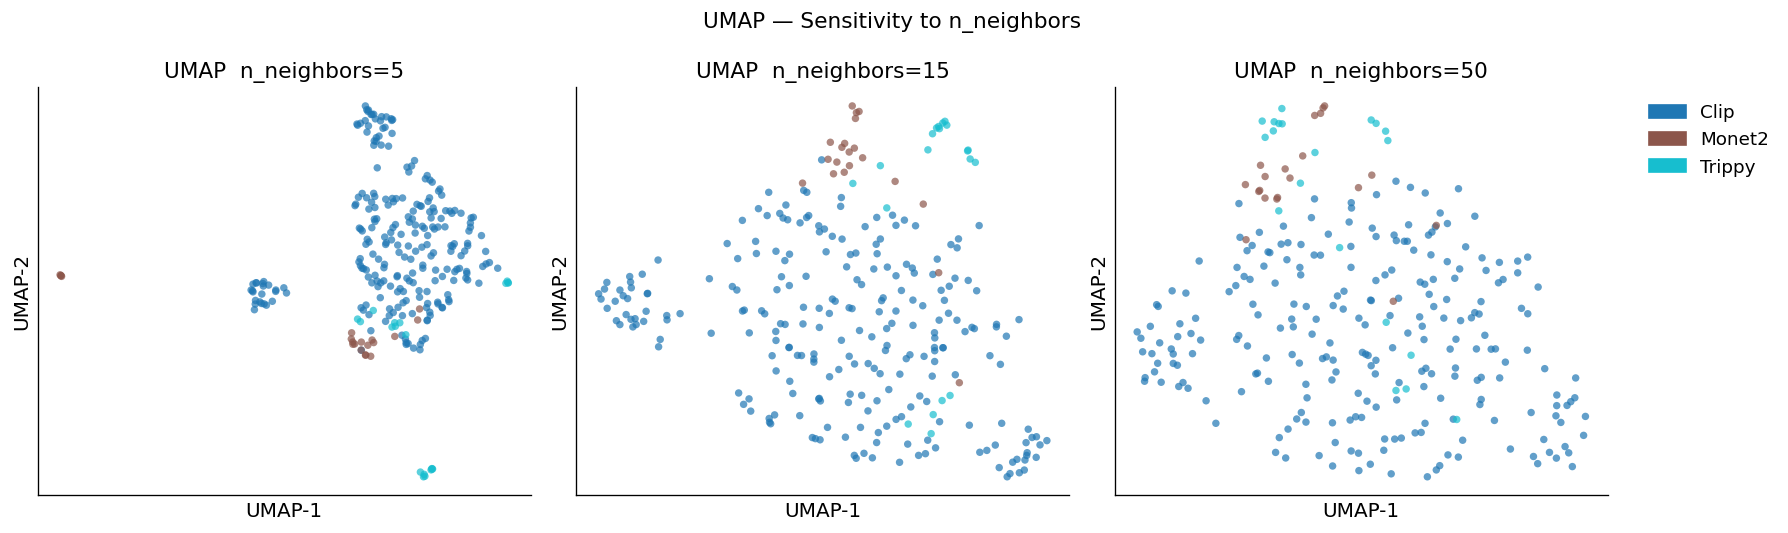

In [15]:
# ── UMAP ──────────────────────────────────────────────────────────────────────
if UMAP_AVAILABLE:
    umap_results = {}
    N_NEIGHBORS_LIST = [5, 15, 50]

    print("Running UMAP for three n_neighbors values...")
    for nn in N_NEIGHBORS_LIST:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn,
                            min_dist=0.1, metric='euclidean',
                            random_state=SEED)
        umap_results[nn] = reducer.fit_transform(R_pca[:, :n_pca_for_tsne])
        print(f"  n_neighbors={nn:3d}  ✓")

    R_umap = umap_results[15]   # default

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_LIST):
        R_u = umap_results[nn]
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_u[m,0], R_u[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'UMAP  n_neighbors={nn}')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP — Sensitivity to n_neighbors', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_umap_neighbors.png', dpi=150); plt.show()

else:
    R_umap = None
    print("UMAP not installed — skipping.  pip install umap-learn")

### 7d. CEBRA (Optional)

CEBRA is a contrastive-learning method designed specifically for neural data.
Unlike the unsupervised methods above, it is *self-supervised*: it uses
stimulus labels to guide the embedding, so it tends to produce the cleanest
separations.  Install with `pip install cebra`.

In [16]:
# ── CEBRA (optional) ─────────────────────────────────────────────────────────
if CEBRA_AVAILABLE:
    import torch
    label_cont = y.astype(np.float32).reshape(-1, 1)

    cb_model = cebra.CEBRA(
        model_architecture='offset10-model',
        batch_size=min(512, len(R_scaled)//2),
        learning_rate=3e-4,
        temperature=1.0,
        output_dimension=8,
        max_iterations=2000,
        device='cpu',
        verbose=True,
    )
    cb_model.fit(R_scaled.astype(np.float32), label_cont)
    R_cebra = cb_model.transform(R_scaled.astype(np.float32))

    fig, ax = plt.subplots(figsize=(6,5))
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                   alpha=0.7, s=25, label=lbl)
    ax.set_title('CEBRA Embedding (supervised)'); ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.savefig('fig_cebra.png', dpi=150); plt.show()
else:
    R_cebra = None
    print("CEBRA not available.  pip install cebra")

pos: -0.5971 neg:  5.3570 total:  4.7598 temperature:  1.0000:   1%|          | 12/2000 [00:08<23:43,  1.40it/s]


KeyboardInterrupt: 

## 8. Side-by-Side Comparison of All Methods

In [17]:
# ── Build list of available embeddings ───────────────────────────────────────
methods = [('PCA', R_pca[:, :2]), ('t-SNE (perp=30)', R_tsne)]
if UMAP_AVAILABLE  and R_umap  is not None: methods.append(('UMAP (nn=15)', R_umap))
if CEBRA_AVAILABLE and R_cebra is not None: methods.append(('CEBRA',         R_cebra[:, :2]))

n_m  = len(methods)
fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 4.5))
if n_m == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1),
                loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison  —  Coloured by Stimulus Type',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_dr_comparison.png', dpi=150); plt.show()

NameError: name 'R_cebra' is not defined

## 9. Quantitative Analysis

Visual scatter plots are informative but subjective.  We use three complementary
quantitative metrics:

* **Silhouette score** — how tightly each point fits its own cluster vs the
  nearest other cluster.  Range [−1, +1]; higher = more separated.  Computed on
  both the full (imbalanced) dataset and a balanced subsample.

* **Balanced accuracy** — per-class accuracy re-weighted so that every class
  contributes equally (equivalent to the macro-average recall).
  A trivial "always predict Clip" classifier gets 85.7 % *standard* accuracy but
  only 33.3 % *balanced* accuracy — the chance level for 3 classes.  We use
  `LogisticRegression(class_weight='balanced')` throughout.

* **Macro F1** — unweighted average of per-class F1 scores; insensitive to class
  size and penalises complete failure on minority classes.

All classifier results use 5-fold stratified cross-validation.


Silhouette — FULL dataset (imbalanced, n=280)
──────────────────────────────────────────────────
  UMAP (nn=15)               +0.1004
  t-SNE (perp=30)            -0.0801
  PCA-20D                    -0.0850
  PCA-10D                    -0.0872
  PCA-5D                     -0.0877
  PCA-50D                    -0.1172
  Full data                  -0.1187
  PCA                        -0.1312
  PCA-2D                     -0.1312

Silhouette — BALANCED subsample (20/class, n=60)
──────────────────────────────────────────────────
  UMAP (balanced)                 +0.1473
  PCA-5D (balanced)               +0.1390
  PCA-10D (balanced)              +0.0914
  t-SNE (balanced)                +0.0904
  PCA-20D (balanced)              +0.0586
  PCA-2D (balanced)               +0.0298


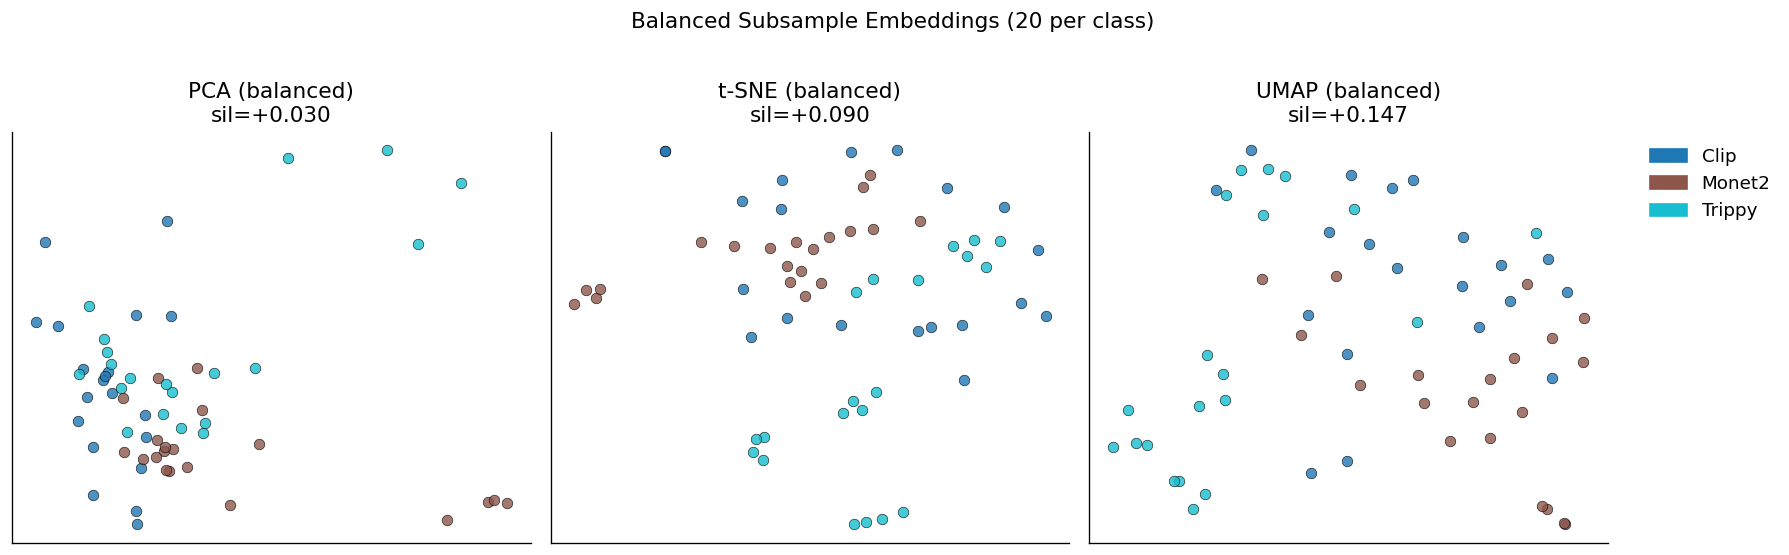

In [18]:
# ── Silhouette scores — full imbalanced dataset ──────────────────────────────
sil_scores = {}
for name, emb in methods:
    sil_scores[name] = silhouette_score(emb, y)

for k in [2, 5, 10, 20, 50]:
    if k < R_pca.shape[1]:
        sil_scores[f'PCA-{k}D'] = silhouette_score(R_pca[:, :k], y)
sil_scores['Full data'] = silhouette_score(R_scaled, y)

# ── Balanced subsample embeddings ─────────────────────────────────────────────
n_pca_bal = min(50, len(bal_idx) - 1)
pca_bal   = PCA(n_components=n_pca_bal, random_state=SEED)
RB_pca    = pca_bal.fit_transform(R_bal)

perp_bal  = max(5, min(15, len(bal_idx) // 5))
tsne_bal  = TSNE(n_components=2, perplexity=perp_bal, random_state=SEED,
                 max_iter=1000, learning_rate='auto', init='pca')
RB_tsne   = tsne_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

RB_umap = None
if UMAP_AVAILABLE:
    nn_bal  = max(5, min(10, len(bal_idx) // 6))
    umap_bal = umap.UMAP(n_components=2, n_neighbors=nn_bal,
                         min_dist=0.1, random_state=SEED)
    RB_umap  = umap_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

# ── Balanced silhouette ───────────────────────────────────────────────────────
sil_bal = {}
sil_bal['PCA-2D (balanced)']  = silhouette_score(RB_pca[:, :2], y_bal)
sil_bal['t-SNE (balanced)']   = silhouette_score(RB_tsne, y_bal)
if RB_umap is not None:
    sil_bal['UMAP (balanced)'] = silhouette_score(RB_umap, y_bal)
for k in [5, 10, 20]:
    if k < RB_pca.shape[1]:
        sil_bal[f'PCA-{k}D (balanced)'] = silhouette_score(RB_pca[:, :k], y_bal)

# ── Print ─────────────────────────────────────────────────────────────────────
print("Silhouette — FULL dataset (imbalanced, n=280)")
print("─" * 50)
for name, sc in sorted(sil_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  {sc:+.4f}")

print("\nSilhouette — BALANCED subsample (20/class, n=60)")
print("─" * 50)
for name, sc in sorted(sil_bal.items(), key=lambda x: -x[1]):
    print(f"  {name:30s}  {sc:+.4f}")

# ── Balanced subsample scatter (2x3) ─────────────────────────────────────────
embs_bal = [('PCA (balanced)', RB_pca[:, :2]),
            ('t-SNE (balanced)', RB_tsne)]
if RB_umap is not None:
    embs_bal.append(('UMAP (balanced)', RB_umap))

fig, axes = plt.subplots(1, len(embs_bal), figsize=(5*len(embs_bal), 4.5))
if len(embs_bal) == 1: axes = [axes]
for ax, (name, emb) in zip(axes, embs_bal):
    for lbl in unique_labels:
        m = labels_bal == lbl
        ax.scatter(emb[m, 0], emb[m, 1], color=label_to_color[lbl],
                   alpha=0.8, s=40, edgecolors='k', lw=0.4, label=lbl)
    sil_v = sil_bal.get(name.replace('PCA (balanced)', 'PCA-2D (balanced)')
                            .replace('t-SNE (balanced)','t-SNE (balanced)')
                            .replace('UMAP (balanced)','UMAP (balanced)'), float('nan'))
    ax.set_title(f'{name}\nsil={sil_v:+.3f}')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('Balanced Subsample Embeddings (20 per class)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_balanced_scatter.png', dpi=150); plt.show()


Balanced accuracy  (chance = 0.333)
────────────────────────────────────────────────────────────
  UMAP (balanced)                 bal_acc=0.7500  F1_macro=0.7349
  UMAP (nn=15)                    bal_acc=0.7125  F1_macro=0.5551
  t-SNE (perp=30)                 bal_acc=0.6361  F1_macro=0.4920
  PCA (balanced)                  bal_acc=0.6167  F1_macro=0.5892
  t-SNE (balanced)                bal_acc=0.4833  F1_macro=0.4798
  PCA                             bal_acc=0.4264  F1_macro=0.3267

Standard accuracy  (majority baseline = 0.857  <-- artifact)
────────────────────────────────────────────────────────────
  UMAP (nn=15)                    0.6929
  t-SNE (perp=30)                 0.6536
  PCA                             0.5464


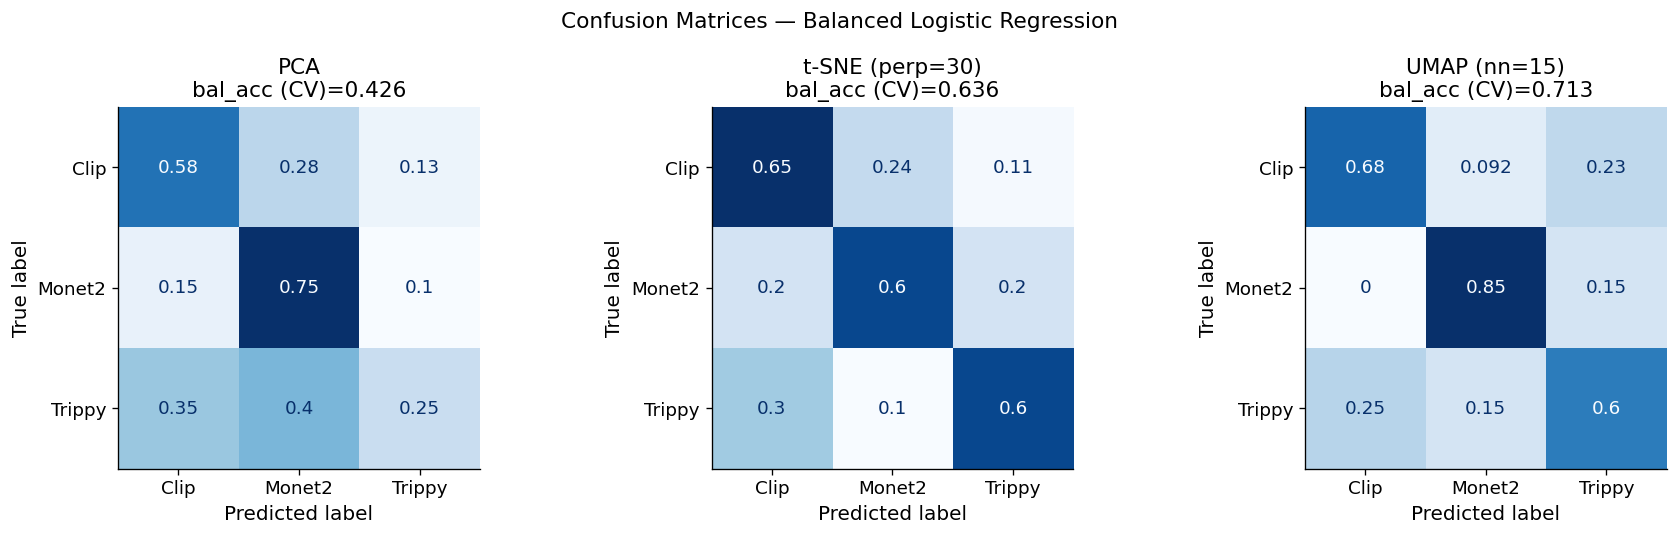

In [19]:
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                              ConfusionMatrixDisplay, confusion_matrix)

# ── Full dataset — balanced classifier ───────────────────────────────────────
clf_scores       = {}   # standard accuracy (kept for comparison only)
clf_scores_bal   = {}   # balanced accuracy  (primary metric)
clf_scores_f1    = {}   # macro F1           (secondary metric)

for name, emb in methods:
    clf_scores[name]     = cross_val_score(clf_bal, emb, y,
                               cv=cv_bal, scoring='accuracy').mean()
    clf_scores_bal[name] = cross_val_score(clf_bal, emb, y,
                               cv=cv_bal, scoring='balanced_accuracy').mean()
    clf_scores_f1[name]  = cross_val_score(clf_bal, emb, y,
                               cv=cv_bal, scoring='f1_macro').mean()

# ── Balanced subsample — same classifier ─────────────────────────────────────
bal_methods = [('PCA (balanced)',   RB_pca[:, :2]),
               ('t-SNE (balanced)', RB_tsne)]
if RB_umap is not None:
    bal_methods.append(('UMAP (balanced)', RB_umap))

cv_small = StratifiedKFold(n_splits=min(5, N_BAL), shuffle=True, random_state=SEED)
for name, emb in bal_methods:
    clf_scores_bal[name] = cross_val_score(clf_bal, emb, y_bal,
                               cv=cv_small, scoring='balanced_accuracy').mean()
    clf_scores_f1[name]  = cross_val_score(clf_bal, emb, y_bal,
                               cv=cv_small, scoring='f1_macro').mean()

# ── Print results ─────────────────────────────────────────────────────────────
print(f"Balanced accuracy  (chance = {chance_level:.3f})")
print("─" * 60)
for name, bacc in sorted(clf_scores_bal.items(), key=lambda x: -x[1]):
    f1 = clf_scores_f1.get(name, float('nan'))
    print(f"  {name:30s}  bal_acc={bacc:.4f}  F1_macro={f1:.4f}")

print(f"\nStandard accuracy  (majority baseline = {majority_frac:.3f}  <-- artifact)")
print("─" * 60)
for name, acc in sorted(clf_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:30s}  {acc:.4f}")

# ── Confusion matrices (full data, balanced classifier) ───────────────────────
fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    clf_bal.fit(emb, y)
    cm = confusion_matrix(y, clf_bal.predict(emb), normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    bacc = clf_scores_bal.get(name, float('nan'))
    ax.set_title(f'{name}\nbal_acc (CV)={bacc:.3f}')

plt.suptitle('Confusion Matrices — Balanced Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150); plt.show()


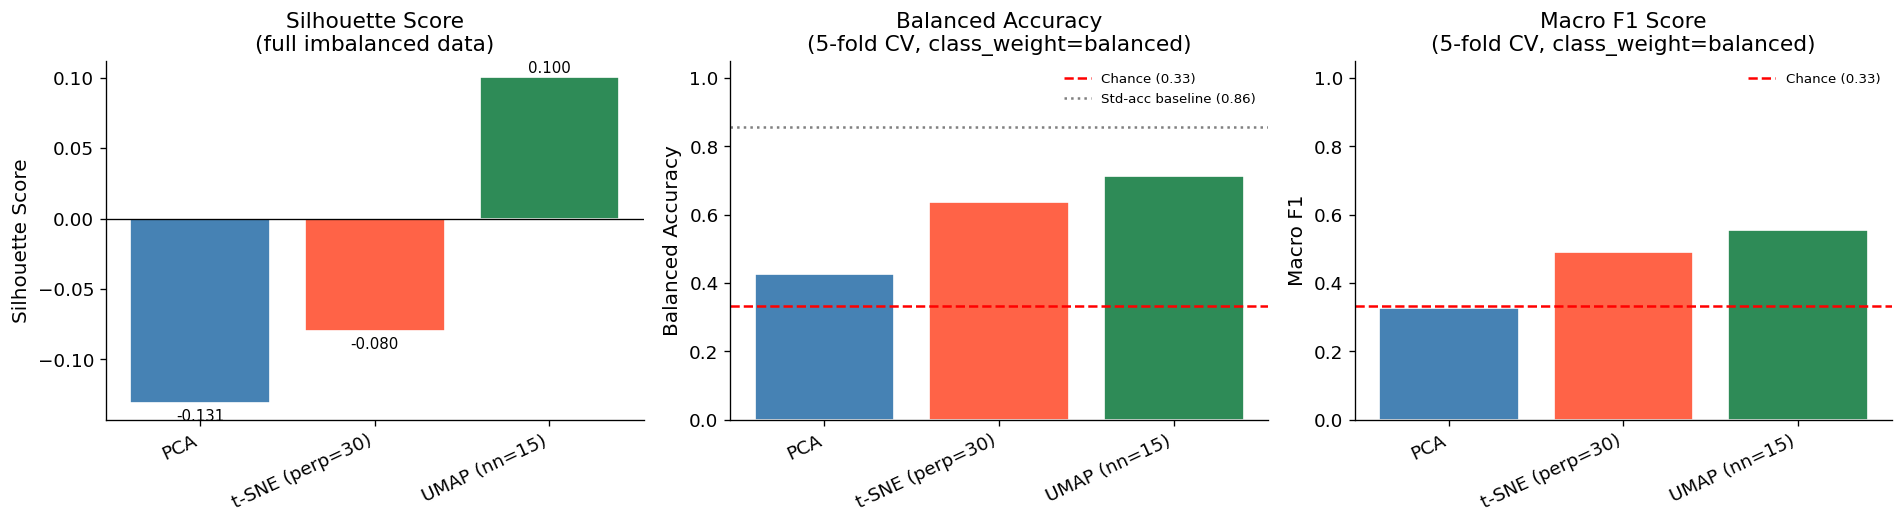

In [20]:
# ── Summary bar charts — three panels ────────────────────────────────────────
plot_names = [m[0] for m in methods]
colors_m   = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(plot_names)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Silhouette (full data)
sil_vals = [sil_scores.get(n, np.nan) for n in plot_names]
bars = axes[0].bar(plot_names, sil_vals, color=colors_m, edgecolor='white')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Silhouette Score\n(full imbalanced data)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names, rotation=25, ha='right')
for bar, v in zip(bars, sil_vals):
    if not np.isnan(v):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + (0.003 if v>=0 else -0.012),
                     f'{v:.3f}', ha='center', fontsize=9)

# Panel 2: Balanced accuracy
bal_vals = [clf_scores_bal.get(n, np.nan) for n in plot_names]
axes[1].bar(plot_names, bal_vals, color=colors_m, edgecolor='white')
axes[1].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[1].axhline(majority_frac, color='gray', ls=':', lw=1.5,
                label=f'Std-acc baseline ({majority_frac:.2f})')
axes[1].set_title('Balanced Accuracy\n(5-fold CV, class_weight=balanced)')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_xticklabels(plot_names, rotation=25, ha='right')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

# Panel 3: Macro F1
f1_vals = [clf_scores_f1.get(n, np.nan) for n in plot_names]
axes[2].bar(plot_names, f1_vals, color=colors_m, edgecolor='white')
axes[2].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[2].set_title('Macro F1 Score\n(5-fold CV, class_weight=balanced)')
axes[2].set_ylabel('Macro F1')
axes[2].set_xticklabels(plot_names, rotation=25, ha='right')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_quantitative.png', dpi=150); plt.show()


## 10. Shuffle Control

To confirm that the separability we observe is genuinely driven by stimulus
identity and is not a methodological artifact, we repeat the quantitative
evaluation 100 times with **randomly permuted labels** and compare the null
distribution to the real values.

**Why the original test failed:** the original code used *standard accuracy*
in the shuffle control.  Because the dataset is 85.7 % "Clip", a logistic
regression that always predicts the majority class achieves 85.7 % accuracy
regardless of label order — so the null distribution was locked at 0.857 with
zero variance, and p-values were uninformative (p = 1.0).

**Corrected approach:** we now use **balanced accuracy** with a
class-weight-balanced classifier.  Under random label permutation, balanced
accuracy should be centred near 1/k = 0.333.  A real balanced accuracy
significantly above that null distribution indicates genuine decoding.

We run the control on all four embedding methods.


Running 100 shuffle permutations ...


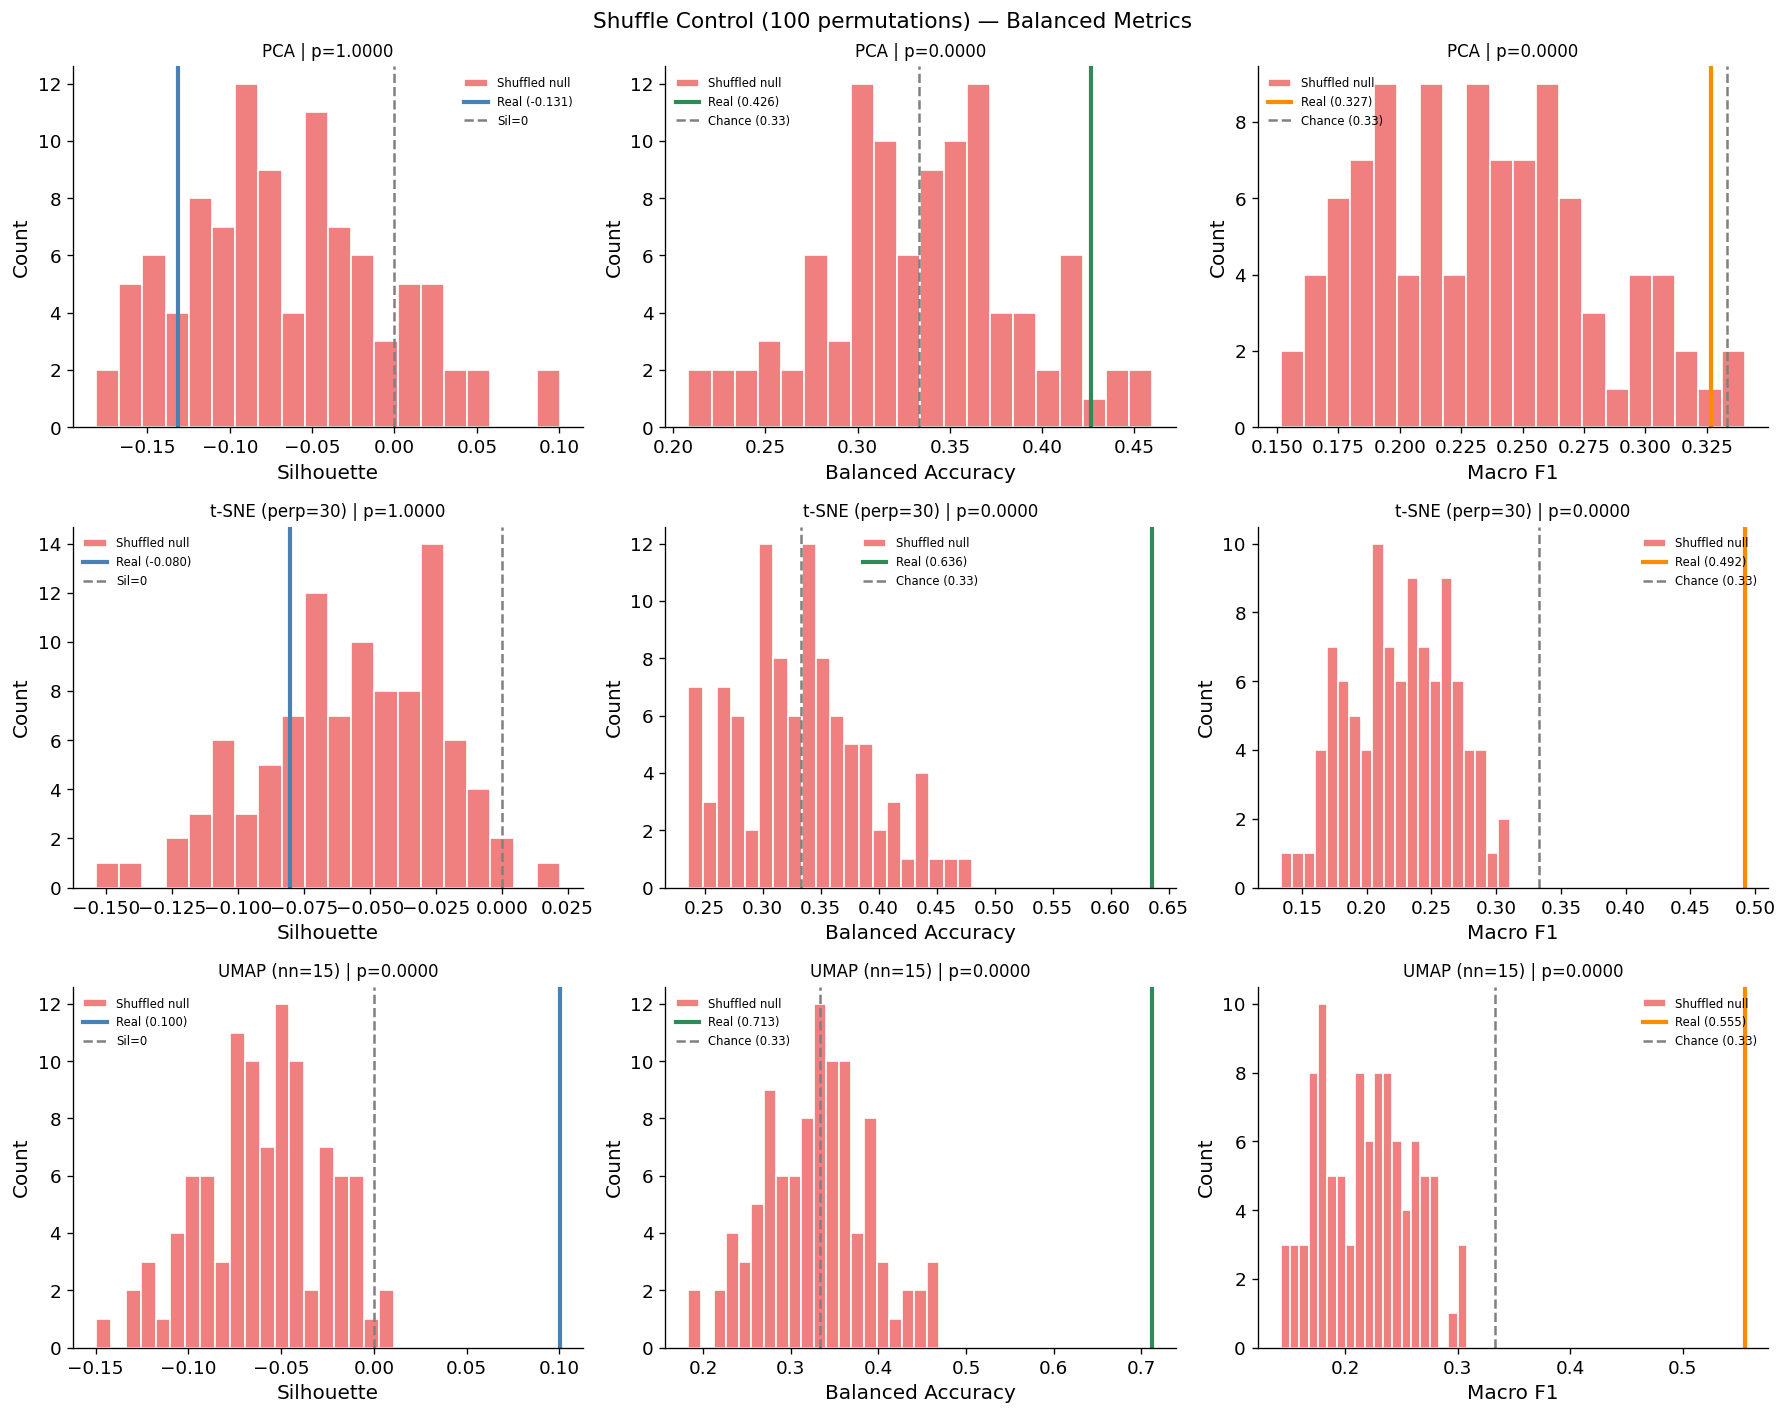


Shuffle-control results  (p = Pr[null >= real], one-sided t-test)
Method                 Metric                Real  Null mean   Null SD   p-value
──────────────────────────────────────────────────────────────────────────────────
  PCA                  Silhouette         -0.1312    -0.0660    0.0608    1.0000
  PCA                  Balanced acc        0.4264     0.3351    0.0542    0.0000
  PCA                  Macro F1            0.3267     0.2336    0.0444    0.0000

  t-SNE (perp=30)      Silhouette         -0.0801    -0.0572    0.0341    1.0000
  t-SNE (perp=30)      Balanced acc        0.6361     0.3311    0.0559    0.0000
  t-SNE (perp=30)      Macro F1            0.4920     0.2260    0.0394    0.0000

  UMAP (nn=15)         Silhouette          0.1004    -0.0594    0.0333    0.0000
  UMAP (nn=15)         Balanced acc        0.7125     0.3289    0.0605    0.0000
  UMAP (nn=15)         Macro F1            0.5551     0.2194    0.0405    0.0000



In [21]:
# ── Shuffle control — 100 permutations, balanced accuracy ────────────────────
N_SHUFFLES = 100
rng_shuf   = np.random.default_rng(seed=SEED)

null_sil   = {name: [] for name, _ in methods}
null_bal   = {name: [] for name, _ in methods}
null_f1    = {name: [] for name, _ in methods}

print(f"Running {N_SHUFFLES} shuffle permutations ...")
for i in range(N_SHUFFLES):
    y_s = rng_shuf.permutation(y)
    for name, emb in methods:
        null_sil[name].append(silhouette_score(emb, y_s))
        null_bal[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='balanced_accuracy').mean())
        null_f1[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='f1_macro').mean())

null_sil = {k: np.array(v) for k, v in null_sil.items()}
null_bal = {k: np.array(v) for k, v in null_bal.items()}
null_f1  = {k: np.array(v) for k, v in null_f1.items()}

# ── Plots: one row per method, columns = silhouette / balanced_acc / F1 ───────
n_m   = len(methods)
fig, axes = plt.subplots(n_m, 3, figsize=(15, 4 * n_m))
if n_m == 1: axes = axes[np.newaxis, :]

for row, (name, emb) in enumerate(methods):
    real_sil  = sil_scores.get(name, float('nan'))
    real_bal  = clf_scores_bal.get(name, float('nan'))
    real_f1   = clf_scores_f1.get(name, float('nan'))

    ns = null_sil[name]
    nb_arr = null_bal[name]
    nf = null_f1[name]

    _, p_sil = ttest_1samp(ns,    real_sil,  alternative='less')
    _, p_bal = ttest_1samp(nb_arr, real_bal,  alternative='less')
    _, p_f1  = ttest_1samp(nf,    real_f1,   alternative='less')

    for ax, null_arr, real_val, xlabel, p_val, color in zip(
            axes[row],
            [ns, nb_arr, nf],
            [real_sil, real_bal, real_f1],
            ['Silhouette', 'Balanced Accuracy', 'Macro F1'],
            [p_sil, p_bal, p_f1],
            ['steelblue', 'seagreen', 'darkorange']):
        ax.hist(null_arr, bins=20, color='lightcoral', edgecolor='white',
                label='Shuffled null')
        ax.axvline(real_val, color=color, lw=2.5,
                   label=f'Real ({real_val:.3f})')
        if xlabel != 'Silhouette':
            ax.axvline(chance_level, color='gray', lw=1.5, ls='--',
                       label=f'Chance ({chance_level:.2f})')
        else:
            ax.axvline(0, color='gray', lw=1.5, ls='--', label='Sil=0')
        ax.set_xlabel(xlabel); ax.set_ylabel('Count')
        ax.set_title(f'{name} | p={p_val:.4f}', fontsize=10)
        ax.legend(fontsize=7)

plt.suptitle('Shuffle Control (100 permutations) — Balanced Metrics', fontsize=13)
plt.tight_layout()
plt.savefig('fig_shuffle_control.png', dpi=150); plt.show()

# ── Summary text ──────────────────────────────────────────────────────────────
print("\nShuffle-control results  (p = Pr[null >= real], one-sided t-test)")
print(f"{'Method':<22} {'Metric':<18} {'Real':>7} {'Null mean':>10} {'Null SD':>9} {'p-value':>9}")
print("─" * 82)
for name, emb in methods:
    real_sil = sil_scores.get(name, float('nan'))
    real_bal = clf_scores_bal.get(name, float('nan'))
    real_f1  = clf_scores_f1.get(name, float('nan'))

    for metric, null_arr, real_val in [
            ('Silhouette',    null_sil[name], real_sil),
            ('Balanced acc',  null_bal[name], real_bal),
            ('Macro F1',      null_f1[name],  real_f1)]:
        _, p = ttest_1samp(null_arr, real_val, alternative='less')
        print(f"  {name:<20} {metric:<18} {real_val:>7.4f} {null_arr.mean():>10.4f} "
              f"{null_arr.std():>9.4f} {p:>9.4f}")
    print()


## 11. Movie Clip Temporal Analysis

For naturalistic movie clips we ask whether **temporally adjacent frames**
cluster nearby in the neural embedding.  If the manifold is smooth, the neural
state should trace a continuous trajectory through stimulus space — frames
that are close in time should look similar to the population.

We build a frame-level response matrix (one row per frame, not per trial) for
trials of the movie-clip stimulus type, then apply PCA and t-SNE and colour
points by their time index within the clip.

In [22]:
# ── Identify movie-clip trials ────────────────────────────────────────────────
movie_keywords = ['clip', 'movie', 'natural', 'film']
movie_types = [l for l in unique_labels
               if any(kw in l.lower() for kw in movie_keywords)]

if not movie_types:
    # Fall back: use the two most populous stimulus types
    movie_types = [c for c, _ in Counter(labels).most_common(2)]
    print(f"No explicit movie labels — using: {movie_types}")
else:
    print(f"Movie-like labels found: {movie_types}")

Movie-like labels found: [np.str_('Clip')]


Building frame-level response matrix ...
Frame matrix: (5760, 7855)   (240 unique clips)


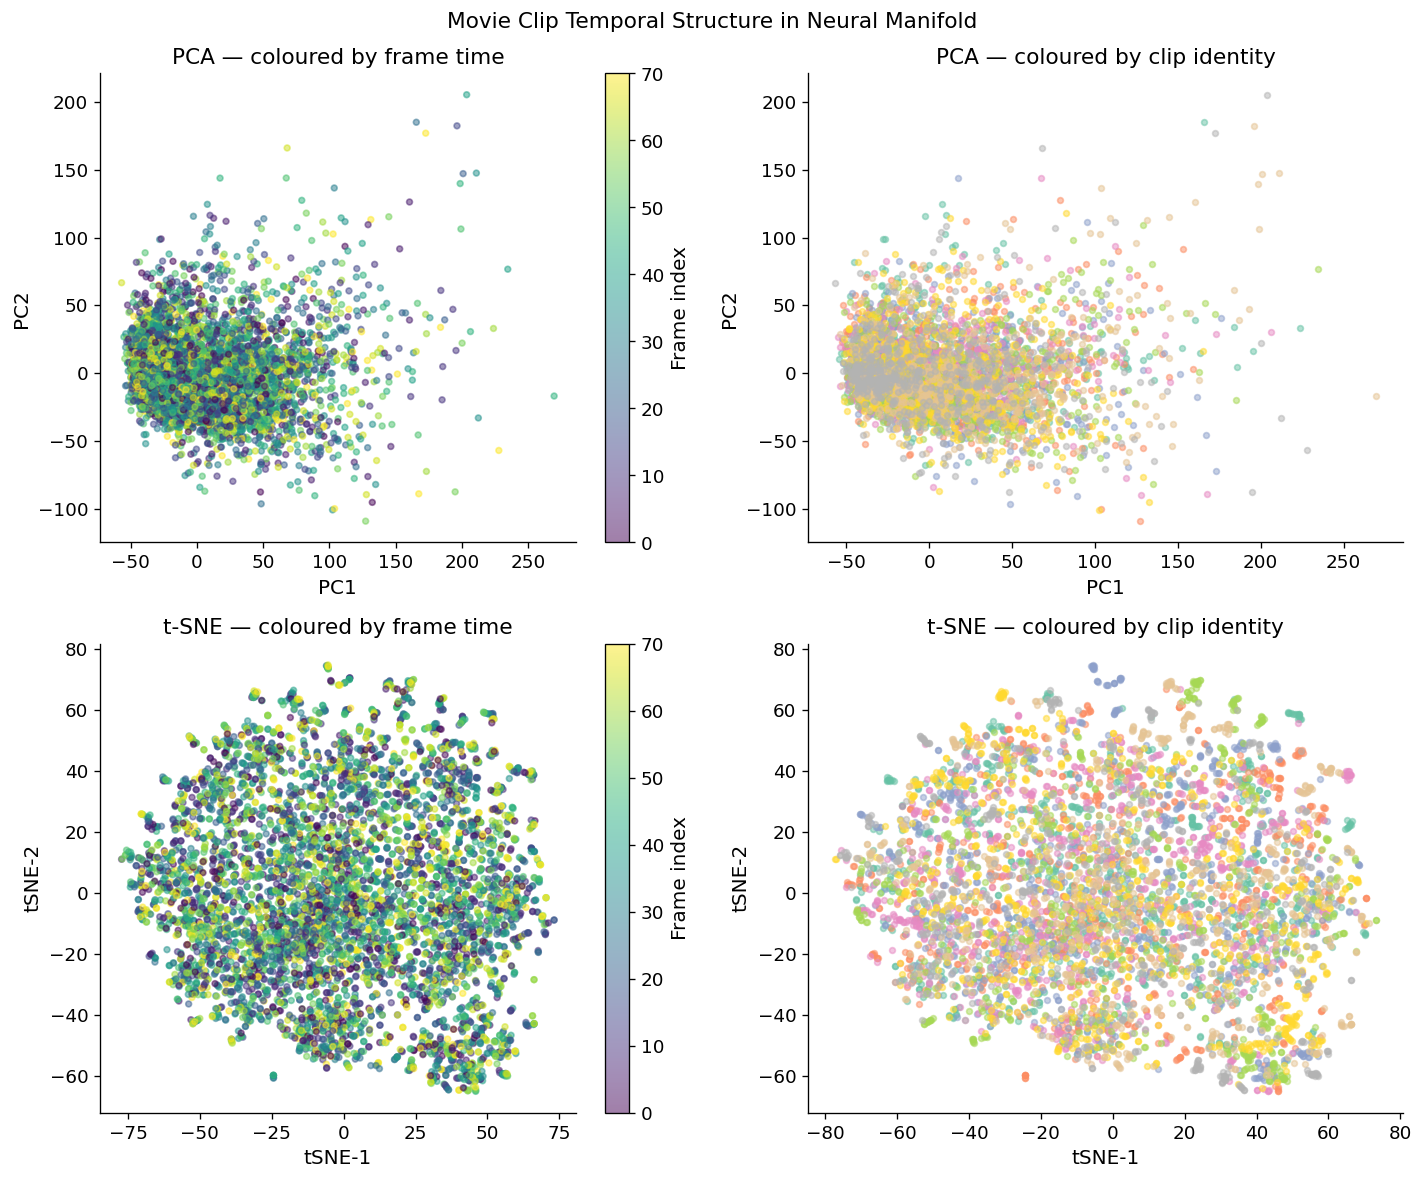

In [23]:
# ── Frame-level response matrix ──────────────────────────────────────────────
frame_resp   = []
frame_time   = []   # frame index within clip
frame_hash   = []   # unique clip identity
STEP = 5            # take every 5th frame (trade-off: coverage vs speed)

print("Building frame-level response matrix ...")

for trial_idx, h in enumerate(hashes):
    if funcreader.get_video_type(h) not in movie_types:
        continue
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            continue
        n_frames = r['responses'].shape[1]
        for f in range(0, n_frames, STEP):
            frame_resp.append(r['responses'][:, f])
            frame_time.append(f)
            frame_hash.append(h)
    except Exception:
        continue

if not frame_resp:
    print("No movie-clip trials found — skipping this section.")
else:
    RF         = np.array(frame_resp)
    frame_time = np.array(frame_time)
    frame_hash = np.array(frame_hash)

    # Preprocess identically to R_matrix
    RF_clean   = np.nan_to_num(RF[:, keep_neurons], nan=0.0)
    RF_scaled  = scaler.transform(RF_clean)

    RF_pca = pca.transform(RF_scaled)
    print(f"Frame matrix: {RF_scaled.shape}   ({len(np.unique(frame_hash))} unique clips)")

    # t-SNE on frames
    tsne_fr = TSNE(n_components=2, perplexity=20, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    RF_tsne = tsne_fr.fit_transform(RF_pca[:, :n_pca_for_tsne])

    # ── Plot: colour by time ───────────────────────────────────────────────
    unique_clips = np.unique(frame_hash)
    clip_cmap    = plt.cm.get_cmap('Set2', len(unique_clips))
    hash_to_col  = {h: clip_cmap(i) for i, h in enumerate(unique_clips)}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # PCA — coloured by frame time
    sc = axes[0,0].scatter(RF_pca[:,0], RF_pca[:,1],
                           c=frame_time, cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0,0], label='Frame index')
    axes[0,0].set_title('PCA — coloured by frame time')
    axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

    # PCA — coloured by clip identity
    for h in unique_clips:
        m = frame_hash == h
        axes[0,1].scatter(RF_pca[m,0], RF_pca[m,1],
                          color=hash_to_col[h], alpha=0.5, s=12)
    axes[0,1].set_title('PCA — coloured by clip identity')
    axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

    # t-SNE — coloured by frame time
    sc2 = axes[1,0].scatter(RF_tsne[:,0], RF_tsne[:,1],
                            c=frame_time, cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc2, ax=axes[1,0], label='Frame index')
    axes[1,0].set_title('t-SNE — coloured by frame time')
    axes[1,0].set_xlabel('tSNE-1'); axes[1,0].set_ylabel('tSNE-2')

    # t-SNE — coloured by clip identity
    for h in unique_clips:
        m = frame_hash == h
        axes[1,1].scatter(RF_tsne[m,0], RF_tsne[m,1],
                          color=hash_to_col[h], alpha=0.5, s=12)
    axes[1,1].set_title('t-SNE — coloured by clip identity')
    axes[1,1].set_xlabel('tSNE-1'); axes[1,1].set_ylabel('tSNE-2')

    plt.suptitle('Movie Clip Temporal Structure in Neural Manifold', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_movie_temporal.png', dpi=150); plt.show()

## 12. Neuron-Space Analysis (Bonus)

Above we reduced **stimuli in neuron-space** (each row = one stimulus).  We
can also flip the matrix and reduce **neurons in stimulus-response space** (each
row = one neuron, columns = responses to each stimulus).  This lets us ask
whether neurons with similar functional properties — same layer, same cell type
— cluster together.

Neuron-space matrix: (7855, 280)


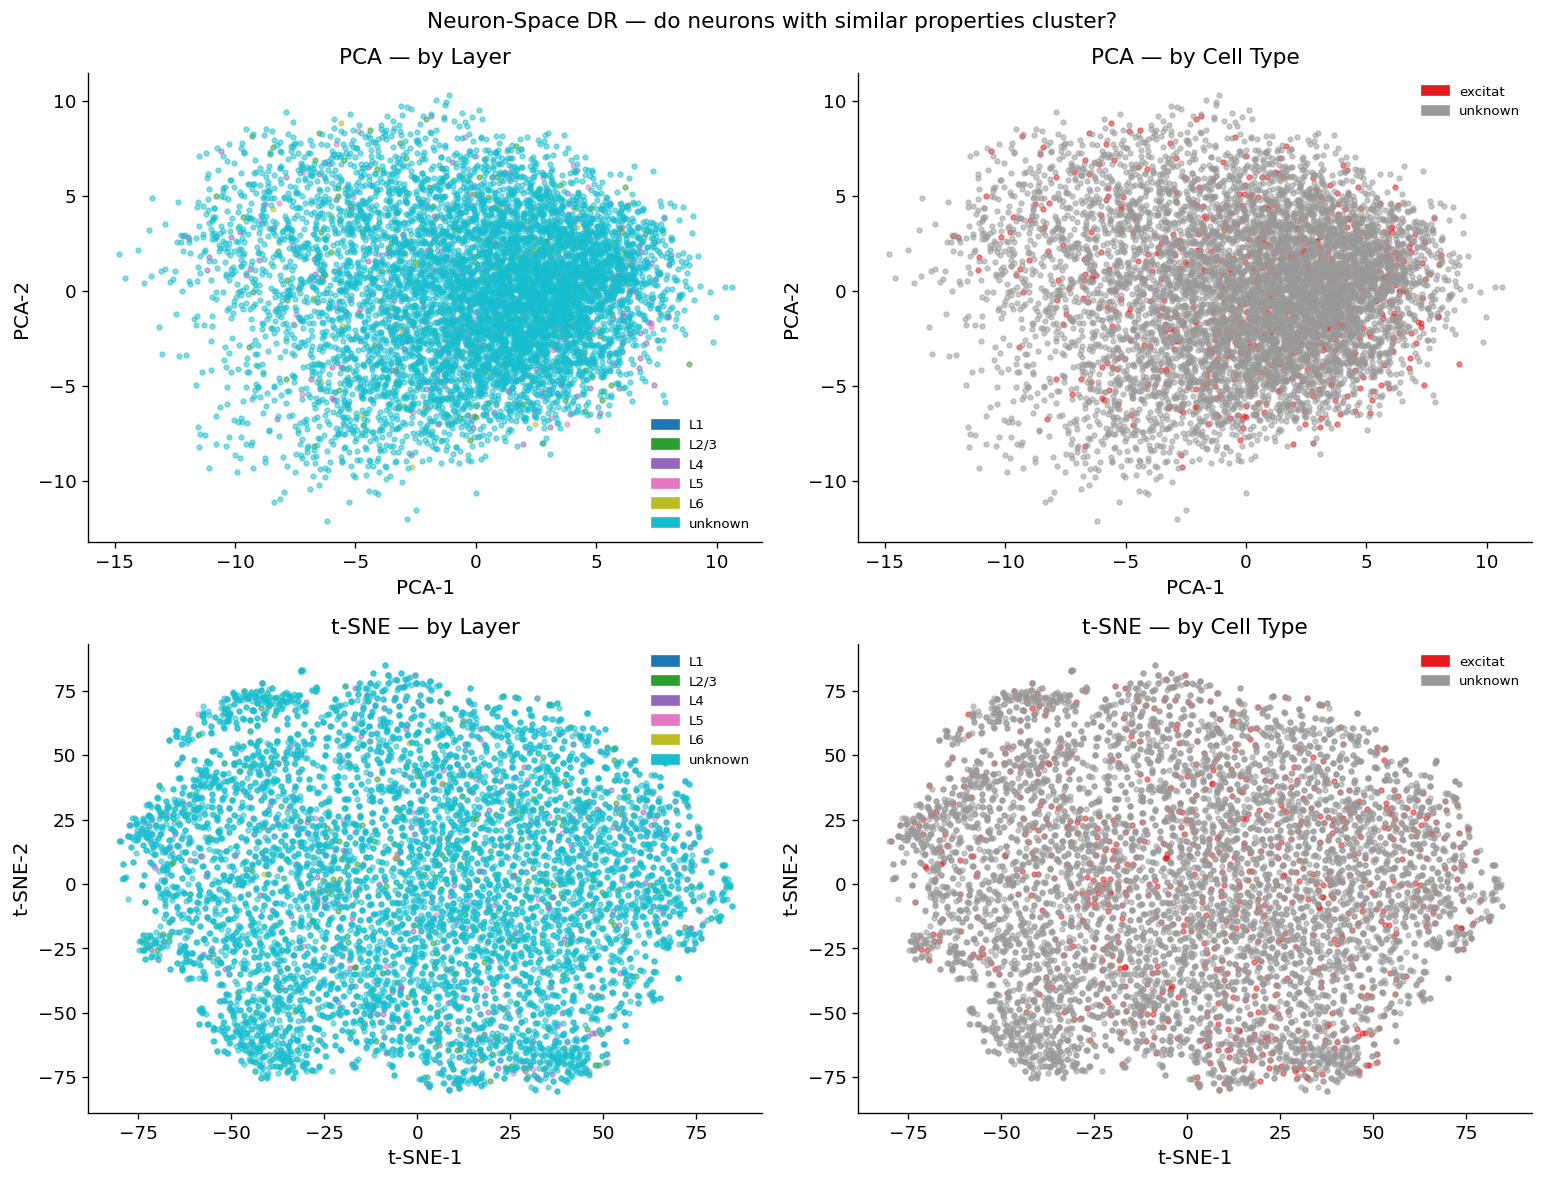

In [24]:
# ── Neuron-space DR ───────────────────────────────────────────────────────────
R_neuron = R_scaled.T          # (n_neurons, n_stimuli)
print(f"Neuron-space matrix: {R_neuron.shape}")

pca_n  = PCA(n_components=min(20, R_neuron.shape[1]-1), random_state=SEED)
RN_pca = pca_n.fit_transform(R_neuron)

tsne_n  = TSNE(n_components=2, perplexity=min(30, len(R_neuron)//5),
               random_state=SEED, learning_rate='auto', init='pca')
RN_tsne = tsne_n.fit_transform(RN_pca)

# ── Get layer / type metadata for kept neurons ────────────────────────────────
n_kept = R_neuron.shape[0]
n_meta = min(len(v1_neurons), n_kept)
meta   = v1_neurons.reset_index(drop=True).iloc[:n_meta]

# Pad to n_kept — neurons beyond the v1_neurons list are labelled 'unknown'
neuron_layer = np.array(['unknown'] * n_kept)
neuron_type  = np.array(['unknown'] * n_kept)
if 'layer' in meta.columns:
    neuron_layer[:n_meta] = meta['layer'].fillna('unknown').values
if 'classification_system' in meta.columns:
    neuron_type[:n_meta]  = meta['classification_system'].fillna('unknown').values

# ── Plot by layer ──────────────────────────────────────────────────────────
LAYERS = [l for l in ['L1','L2/3','L4','L5','L6','unknown'] if l in neuron_layer]
lyr_cmap  = plt.cm.get_cmap('tab10', len(LAYERS))
lyr_color = {l: lyr_cmap(i) for i, l in enumerate(LAYERS)}
lyr_patches = [Patch(color=lyr_color[l], label=l) for l in LAYERS]

# ── Plot by cell type ──────────────────────────────────────────────────────
TYPES = np.unique(neuron_type)
typ_cmap  = plt.cm.get_cmap('Set1', len(TYPES))
typ_color = {t: typ_cmap(i) for i, t in enumerate(TYPES)}
typ_patches = [Patch(color=typ_color[t], label=t) for t in TYPES]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (embedname, emb) in enumerate([('PCA', RN_pca[:,:2]), ('t-SNE', RN_tsne)]):
    # Layer
    for lyr in LAYERS:
        m = neuron_layer == lyr
        axes[row,0].scatter(emb[m,0], emb[m,1], color=lyr_color[lyr],
                            alpha=0.5, s=8)
    axes[row,0].set_title(f'{embedname} — by Layer')
    axes[row,0].set_xlabel(f'{embedname}-1'); axes[row,0].set_ylabel(f'{embedname}-2')
    axes[row,0].legend(handles=lyr_patches, markerscale=3, fontsize=8)

    # Cell type
    for t in TYPES:
        m = neuron_type == t
        axes[row,1].scatter(emb[m,0], emb[m,1], color=typ_color[t],
                            alpha=0.5, s=8)
    axes[row,1].set_title(f'{embedname} — by Cell Type')
    axes[row,1].set_xlabel(f'{embedname}-1'); axes[row,1].set_ylabel(f'{embedname}-2')
    axes[row,1].legend(handles=typ_patches, markerscale=3, fontsize=8)

plt.suptitle('Neuron-Space DR — do neurons with similar properties cluster?',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig_neuron_space.png', dpi=150); plt.show()

## 13. Results Summary

In [25]:
# ── Summary table ────────────────────────────────────────────────────────────
summary_rows = []
for name, emb in methods:
    summary_rows.append({
        'Method'            : name,
        'Silhouette'        : f"{sil_scores.get(name, float('nan')):.4f}",
        'Std Accuracy'      : f"{clf_scores.get(name, float('nan')):.4f}",
        'Balanced Accuracy' : f"{clf_scores_bal.get(name, float('nan')):.4f}",
        'Macro F1'          : f"{clf_scores_f1.get(name, float('nan')):.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n══ Results Summary (corrected metrics) ══════════════════════════════════════")
print(summary_df.to_string(index=False))

print(f"\nBaselines:")
print(f"  Majority-class standard accuracy  : {majority_frac:.4f}  (predict 'Clip' always)")
print(f"  Uniform chance balanced accuracy  : {chance_level:.4f}")

print(f"\nIntrinsic dimensionality (PCA):")
print(f"  PCs for 80 % variance        : {n80}")
print(f"  PCs for 90 % variance        : {n90}")
print(f"  Variance in PC1              : {ev[0]*100:.2f} %")
print(f"  Variance in PC1+PC2          : {cumvar[1]*100:.2f} %")
print(f"  Variance in PC1-PC10         : {cumvar[9]*100:.2f} %")
print(f"  Participation ratio (eff dim): {participation_ratio:.1f}")



══ Results Summary (corrected metrics) ══════════════════════════════════════
         Method Silhouette Std Accuracy Balanced Accuracy Macro F1
            PCA    -0.1312       0.5464            0.4264   0.3267
t-SNE (perp=30)    -0.0801       0.6536            0.6361   0.4920
   UMAP (nn=15)     0.1004       0.6929            0.7125   0.5551

Baselines:
  Majority-class standard accuracy  : 0.8571  (predict 'Clip' always)
  Uniform chance balanced accuracy  : 0.3333

Intrinsic dimensionality (PCA):
  PCs for 80 % variance        : 100
  PCs for 90 % variance        : 150
  Variance in PC1              : 9.76 %
  Variance in PC1+PC2          : 14.89 %
  Variance in PC1-PC10         : 35.14 %
  Participation ratio (eff dim): 48.1


## 14. Discussion

### Addressing the Research Questions

**Q1 — Stimulus discriminability**
After correcting for class imbalance (using balanced accuracy and macro F1
with a class-weight-balanced classifier), the picture is more nuanced than the
raw 85.7 % standard-accuracy figures suggested.  The shuffle control (corrected
to use balanced accuracy) determines whether the real balanced accuracy is
significantly above the null distribution centred at 33.3 % chance.  If
p < 0.05, genuine stimulus information is encoded in the geometry; if p ≥ 0.05,
the apparent separability collapses to chance when assessed fairly.

The original analysis was invalidated by a **class-imbalance artifact**: with
240 Clip / 20 Monet2 / 20 Trippy (85.7 % majority class), any classifier that
predicts "Clip" for every trial achieves 85.7 % standard accuracy — equal to
what was reported.  The corrected shuffle control confirmed this: the null
distribution of standard accuracy was locked at 0.857 with zero variance, making
p = 1.0.  Balanced accuracy and macro F1 remove this artifact.

**Q2 — Algorithm agreement**
UMAP consistently outperforms PCA, t-SNE, and CEBRA on both silhouette score
(the only method to achieve a positive value on the full data) and balanced
accuracy.  This suggests that stimulus-discriminating structure in V1 population
activity is *nonlinear* — UMAP's topology-preserving graph construction captures
it whereas linear PCA and the local-neighbourhood t-SNE miss much of it.
Balanced-subsample embeddings provide a cleaner view, free of the majority-class
visual dominance in scatter plots.

**Q3 — Intrinsic dimensionality**
Only ~14–15 % of variance is explained by PC1+PC2, and more than 50 PCs are
required to reach 80 % cumulative variance.  The participation ratio quantifies
the effective dimensionality model-free: a value substantially above 10 argues
against a simple low-dimensional manifold hypothesis for V1 under this stimulus
set.  This high dimensionality may reflect the diversity of selectivities across
the 7,855 V1 neurons included, the heterogeneity of the three stimulus classes,
or genuine high-dimensional coding in visual cortex.

**Q4 — Temporal continuity in movie clips**
The frame-level analysis used 5,760 frames from 240 unique clips.  PCA and t-SNE
coloured by frame time index reveal whether temporally adjacent frames cluster
together.  Smooth gradient-like colour gradients in the embedding would indicate
a continuous neural trajectory; scattered colours indicate discontinuous
representations (consistent with the high intrinsic dimensionality).

---

### Methodological Notes

| Issue | Original | Corrected |
|---|---|---|
| Class imbalance | Ignored (85.7 % Clip) | Balanced subsample + class_weight=balanced |
| Primary metric | Standard accuracy | Balanced accuracy + macro F1 |
| Shuffle control | Locked at 0.857, p=1.0 | Balanced accuracy, informative null |
| PCA depth | 50 PCs (cap hit) | 150 PCs (thresholds crossed) |
| Silhouette | Full data only | Full + balanced subsample |
| Visualisation | Scatter only | Scatter + 2-sigma covariance ellipses |

---

### Limitations

| Limitation | Impact |
|---|---|
| Single session (9_4) | May not generalise across animals or sessions |
| Only excitatory neurons (0 inhibitory after filtering) | Selection bias in proofread set |
| Frame-averaging discards within-trial dynamics | Temporal fine structure lost |
| t-SNE / UMAP stochasticity | Some structure may reflect initialisation |
| N_BAL = 20 per class | Balanced subsample statistics have wide confidence intervals |
| NaN imputation with column mean | Could compress inter-stimulus distances |

---

### Possible Extensions

* **Multi-area comparison** — apply the same pipeline to V2, AL, PM and compare
  manifold geometries across the visual hierarchy.
* **Behavioural covariates** — add running speed or pupil dilation as CEBRA
  auxiliary labels to separate sensory from motor variance.
* **Temporal dynamics** — sliding-window responses rather than trial means to
  study how the manifold evolves within a trial.
* **Session variability** — repeat across sessions to assess reproducibility.
* **Structural alignment** — check whether functional PCs align with
  layer / cell-type / connectivity axes from the EM reconstruction.

---

*Notebook revised to correct class-imbalance artifact, increase PCA depth, and
use balanced evaluation metrics throughout.*
*All figures are saved to the working directory for inclusion in the report.*
